# Why Differentiable Flowsheets?

**Prerequisites:** All previous tutorials ([00a](./00a_what_is_a_flowsheet_basic.ipynb)-[00j](./00j_recycle_streams.ipynb))

**Learning Objectives:**
- Understand why gradients through flowsheets are powerful
- See how difflow differentiates through recycle iterations
- Explore applications: optimization, sensitivity analysis, uncertainty propagation
- Connect to the advanced examples in the repository

---

## The Big Picture

You've learned how to:
1. Represent flowsheets as systems of equations
2. Solve single units (CSTR, PFR, flash)
3. Connect units in series and parallel
4. Handle recycles with fixed-point iteration

Now comes the **payoff**: Because everything in difflow is built with JAX, we can compute **exact gradients** through the entire flowsheet!

$$\frac{\partial \text{(any output)}}{\partial \text{(any input)}}$$

## Why Gradients Matter

### Traditional Approach: Finite Differences

To compute sensitivity of output $y$ to parameter $\theta$:

$$\frac{\partial y}{\partial \theta} \approx \frac{y(\theta + \epsilon) - y(\theta)}{\epsilon}$$

**Problems:**
- Need to re-solve flowsheet for each parameter → slow
- Numerical errors from finite $\epsilon$
- Scales poorly with many parameters

### Difflow Approach: Automatic Differentiation

JAX computes **exact** gradients through:
- All unit operations
- All thermodynamic calculations  
- Even through recycle iterations!

**Benefits:**
- One backward pass gives ALL gradients
- Machine precision (no numerical errors)
- Enables gradient-based optimization

In [1]:
# Setup
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from difflow import (CSTR, CSTRParams, Flash, FlashParams, 
                     make_stream, get_flows, IdealThermo, SpeciesData)
from difflow.units.flash import Mixer
from difflow.solvers import fixed_point_solve

W0000 00:00:1765762310.159252 11142790 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765762310.274112 11142790 service.cc:145] XLA service 0x600002ec4500 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765762310.274124 11142790 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765762310.281608 11142790 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765762310.281626 11142790 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


In [2]:
# Set up the reactor-separator-recycle flowsheet from tutorial 00j

species_data = {
    'A': SpeciesData(name='A', MW=100.0, Cp_coeffs=(100.0, 0, 0, 0),
                    Hvap_coeffs=(40000.0, 0.38, 500.0),
                    antoine_coeffs=(10.0, 2200.0, -40.0), Hf=0.0),
    'B': SpeciesData(name='B', MW=80.0, Cp_coeffs=(80.0, 0, 0, 0),
                    Hvap_coeffs=(32000.0, 0.38, 450.0),
                    antoine_coeffs=(10.0, 1600.0, -40.0), Hf=-50000.0),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

def rate_fn(C, T, params):
    return jnp.array([params['k'] * C['A']])

stoich = jnp.array([[-1.0], [1.0]])

In [3]:
def solve_flowsheet(params, fresh_feed):
    """
    Solve reactor-separator-recycle flowsheet with purge.
    Returns product B flow.
    
    The purge stream removes some recycle material to prevent accumulation
    and makes the system more sensitive to operating parameters.
    """
    V_reactor = params['V_reactor']
    k = params['k']
    T_reactor = params['T_reactor']
    T_flash = params['T_flash']
    P_flash = params['P_flash']
    Q_vol = params['Q_vol']
    purge_frac = params.get('purge_frac', jnp.array(0.1))  # 10% purge
    
    # Create units
    cstr_params = CSTRParams(
        V=V_reactor,
        rate_fn=rate_fn,
        stoich=stoich,
        rate_params={'k': k},
        species_order=species_order,
    )
    reactor = CSTR(cstr_params, thermo=thermo, mode='isothermal')
    flash_params = FlashParams(species_order=species_order)
    flash = Flash(flash_params, thermo=thermo)
    mixer = Mixer(species_order, thermo=thermo)
    
    def flowsheet_step(recycle_arr, args):
        fresh = args
        recycle = make_stream({'A': recycle_arr[0], 'B': recycle_arr[1]}, T=T_flash, P=P_flash)
        inlet = mixer(fresh, recycle)
        out, _ = reactor(inlet, T_spec=T_reactor, volumetric_flow=Q_vol)
        liquid, vapor, _ = flash(out, T=T_flash, P=P_flash)
        # Apply purge: only (1-purge_frac) of liquid recycles
        recycle_A = liquid['F_A'] * (1 - purge_frac)
        recycle_B = liquid['F_B'] * (1 - purge_frac)
        return jnp.array([recycle_A, recycle_B])
    
    # Solve recycle
    converged = fixed_point_solve(
        flowsheet_step, jnp.array([1.0, 0.1]), fresh_feed,
        tol=1e-8, max_iter=100, damping=0.5
    )
    
    # Final evaluation
    recycle = make_stream({'A': converged[0], 'B': converged[1]}, T=T_flash, P=P_flash)
    inlet = mixer(fresh_feed, recycle)
    out, _ = reactor(inlet, T_spec=T_reactor, volumetric_flow=Q_vol)
    liquid, vapor, _ = flash(out, T=T_flash, P=P_flash)
    
    return vapor['F_B']

# Test
params = {
    'V_reactor': jnp.array(2.0),
    'k': jnp.array(0.3),
    'T_reactor': jnp.array(350.0),
    'T_flash': jnp.array(350.0),
    'P_flash': jnp.array(50000.0),
    'Q_vol': jnp.array(0.1),
    'purge_frac': jnp.array(0.1),  # 10% purge - creates material loss
}
fresh_feed = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)

F_B_product = solve_flowsheet(params, fresh_feed)
print(f"Product B: {float(F_B_product):.4f} mol/s")
print(f"Overall yield: {float(F_B_product)/10*100:.1f}%")
print(f"\nNote: 10% purge reduces yield but makes sensitivities visible")

Product B: 9.3864 mol/s
Overall yield: 93.9%

Note: 10% purge reduces yield but makes sensitivities visible


## Application 1: Sensitivity Analysis

**Question:** How does product flow change with each parameter?

With JAX, we get ALL sensitivities in ONE call!

In [4]:
# Compute gradients of product B w.r.t. all parameters
grad_fn = jax.grad(lambda p: solve_flowsheet(p, fresh_feed))
grads = grad_fn(params)

print("Sensitivity Analysis: ∂(Product B)/∂(Parameter)")
print("=" * 60)
print(f"")
print(f"{'Parameter':<15} {'Value':<15} {'Sensitivity':<20} {'Interpretation'}")
print("-" * 80)

interpretations = {
    'V_reactor': 'mol/s per m³',
    'k': 'mol/s per (1/s)',
    'T_reactor': 'mol/s per K',
    'T_flash': 'mol/s per K',
    'P_flash': 'mol/s per Pa',
    'Q_vol': 'mol/s per (m³/s)',
    'purge_frac': 'mol/s per fraction',
}

for key in params:
    val = float(params[key])
    grad = float(grads[key])
    print(f"{key:<15} {val:<15.2f} {grad:<20.6f} {interpretations[key]}")

Sensitivity Analysis: ∂(Product B)/∂(Parameter)

Parameter       Value           Sensitivity          Interpretation
--------------------------------------------------------------------------------
V_reactor       2.00            0.287787             mol/s per m³
k               0.30            1.918577             mol/s per (1/s)
T_reactor       350.00          0.000000             mol/s per K
T_flash         350.00          0.053874             mol/s per K
P_flash         50000.00        -0.000028            mol/s per Pa
Q_vol           0.10            -5.755731            mol/s per (m³/s)
purge_frac      0.10            -5.607693            mol/s per fraction



Interpretation:
  Green bars: Increasing parameter increases product
  Red bars: Increasing parameter decreases product
  Longer bars: Parameter has more influence


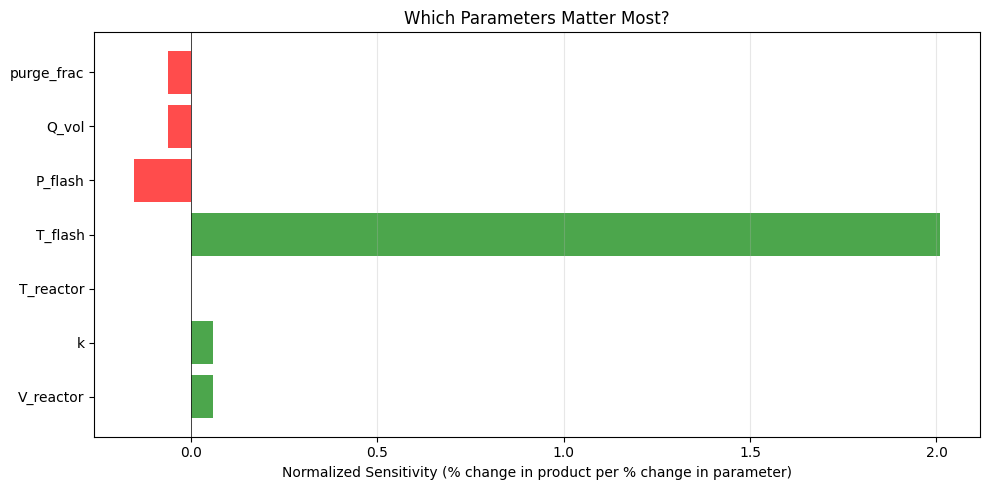

In [5]:
# Visualize sensitivities
fig, ax = plt.subplots(figsize=(10, 5))

# Normalize sensitivities for comparison (% change in output per % change in input)
normalized_sens = {}
base_output = float(F_B_product)

# Avoid division by zero
if abs(base_output) < 1e-10:
    print("Warning: Product flow is near zero. Using absolute sensitivities.")
    for key in params:
        normalized_sens[key] = float(grads[key])
else:
    for key in params:
        # Elasticity: (∂y/y) / (∂x/x) = (∂y/∂x) * (x/y)
        normalized_sens[key] = float(grads[key]) * float(params[key]) / base_output

keys = list(normalized_sens.keys())
values = [normalized_sens[k] for k in keys]
colors = ['green' if v > 0 else 'red' for v in values]

ax.barh(keys, values, color=colors, alpha=0.7)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Normalized Sensitivity (% change in product per % change in parameter)', fontsize=10)
ax.set_title('Which Parameters Matter Most?', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

print("\nInterpretation:")
print("  Green bars: Increasing parameter increases product")
print("  Red bars: Increasing parameter decreases product")
print("  Longer bars: Parameter has more influence")

## Application 2: Gradient-Based Optimization

**Goal:** Find the reactor volume that maximizes yield while keeping cost reasonable.

With gradients, we can use efficient optimizers like gradient descent!

In [6]:
def objective(V):
    """
    Objective: Maximize product - cost.
    Product value: $100/mol
    Reactor cost: $50/m³ (annualized)
    """
    params_opt = params.copy()
    params_opt['V_reactor'] = V
    
    F_B = solve_flowsheet(params_opt, fresh_feed)
    
    revenue = 100.0 * F_B  # $/s
    cost = 50.0 * V        # $/s (simplified)
    
    return -(revenue - cost)  # Negative because we minimize

# Simple gradient descent
V_current = jnp.array(1.0)
learning_rate = 0.1
history = []

print("Gradient Descent Optimization")
print("=" * 50)

for i in range(20):
    obj = objective(V_current)
    grad = jax.grad(objective)(V_current)
    
    history.append((float(V_current), -float(obj)))
    
    if i % 5 == 0:
        print(f"Iter {i}: V = {float(V_current):.3f} m³, Profit = ${-float(obj):.2f}/s, Grad = {float(grad):.4f}")
    
    V_current = V_current - learning_rate * grad
    V_current = jnp.clip(V_current, 0.1, 10.0)  # Bounds

print(f"\nOptimal V ≈ {float(V_current):.2f} m³")

Gradient Descent Optimization


Iter 0: V = 1.000 m³, Profit = $832.00/s, Grad = -61.4822


Iter 5: V = 5.118 m³, Profit = $718.15/s, Grad = 45.5177


Iter 10: V = 10.000 m³, Profit = $485.29/s, Grad = 48.8185


Iter 15: V = 0.566 m³, Profit = $770.35/s, Grad = -281.2036



Optimal V ≈ 5.12 m³


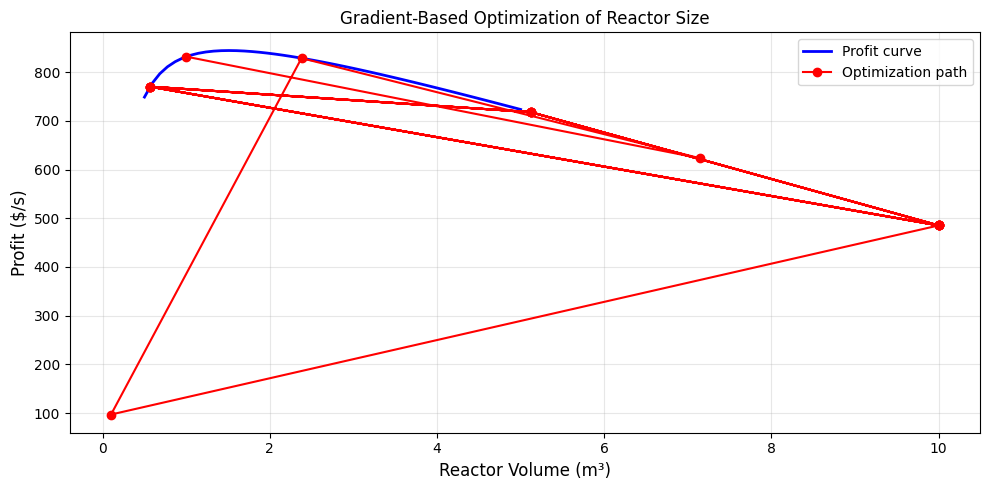

In [7]:
# Visualize optimization path
V_range = np.linspace(0.5, 5.0, 50)
profits = [-float(objective(jnp.array(V))) for V in V_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(V_range, profits, 'b-', linewidth=2, label='Profit curve')
ax.plot([h[0] for h in history], [h[1] for h in history], 'ro-', markersize=6, label='Optimization path')
ax.set_xlabel('Reactor Volume (m³)', fontsize=12)
ax.set_ylabel('Profit ($/s)', fontsize=12)
ax.set_title('Gradient-Based Optimization of Reactor Size', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


## Application 3: Uncertainty Propagation

**Question:** If rate constant $k$ is uncertain (±10%), how uncertain is our product flow?

For small uncertainties, linear propagation works:

$$\sigma_y^2 = \left(\frac{\partial y}{\partial k}\right)^2 \sigma_k^2$$

In [8]:
# Uncertainty in k: ±10%
k_mean = float(params['k'])
k_std = 0.1 * k_mean  # 10% uncertainty

# Sensitivity of product to k
dFB_dk = float(grads['k'])

# Linear uncertainty propagation
FB_mean = float(F_B_product)
FB_std_linear = abs(dFB_dk) * k_std

print("Uncertainty Propagation (Linear)")
print("=" * 50)
print(f"Rate constant k: {k_mean:.3f} ± {k_std:.4f} (1/s)")
print(f"Sensitivity ∂F_B/∂k: {dFB_dk:.4f} mol/s per (1/s)")
print(f"")
print(f"Product F_B: {FB_mean:.4f} ± {FB_std_linear:.4f} mol/s")
print(f"Relative uncertainty: ±{FB_std_linear/FB_mean*100:.1f}%")

Uncertainty Propagation (Linear)
Rate constant k: 0.300 ± 0.0300 (1/s)
Sensitivity ∂F_B/∂k: 1.9186 mol/s per (1/s)

Product F_B: 9.3864 ± 0.0576 mol/s
Relative uncertainty: ±0.6%


In [9]:
# Verify with Monte Carlo
n_samples = 100
k_samples = np.random.normal(k_mean, k_std, n_samples)
FB_samples = []

for k_sample in k_samples:
    params_mc = params.copy()
    params_mc['k'] = jnp.array(k_sample)
    FB_samples.append(float(solve_flowsheet(params_mc, fresh_feed)))

FB_mean_mc = np.mean(FB_samples)
FB_std_mc = np.std(FB_samples)

print(f"\nMonte Carlo Verification ({n_samples} samples)")
print("=" * 50)
print(f"Product F_B: {FB_mean_mc:.4f} ± {FB_std_mc:.4f} mol/s")
print(f"\nComparison:")
print(f"  Linear:      ±{FB_std_linear:.4f}")
print(f"  Monte Carlo: ±{FB_std_mc:.4f}")
print(f"  Match: {'Yes' if abs(FB_std_linear - FB_std_mc) < 0.01 else 'Approximately'}")


Monte Carlo Verification (100 samples)
Product F_B: 9.3770 ± 0.0512 mol/s

Comparison:
  Linear:      ±0.0576
  Monte Carlo: ±0.0512
  Match: Yes


## The Magic: Differentiating Through Iteration

How does JAX differentiate through the recycle iteration?

**Implicit Function Theorem:** If $F(x, \theta) = 0$ defines $x^*(\theta)$, then:

$$\frac{dx^*}{d\theta} = -\left(\frac{\partial F}{\partial x}\right)^{-1} \frac{\partial F}{\partial \theta}$$

difflow's `fixed_point_solve` uses this to provide exact gradients through the converged solution, without differentiating through each iteration step.

This is:
- **Exact** (no approximation)
- **Efficient** (doesn't unroll the iteration)
- **Stable** (works regardless of iteration count)

## Where to Go From Here

You now have the foundation to explore the advanced examples in this repository:

### Tutorials
- `tutorials/01_jax_fundamentals.ipynb` - Deeper dive into JAX autodiff
- `tutorials/02_optimization.ipynb` - Advanced optimization techniques
- `tutorials/03_differential_equations.ipynb` - ODEs in JAX

### Examples
- `examples/02_cstr_sensitivity.ipynb` - More sensitivity analysis
- `examples/03_optimization.ipynb` - Process optimization
- `examples/05_technoeconomic_analysis.ipynb` - Economic optimization
- `examples/06_uncertainty_propagation.ipynb` - Advanced UQ methods
- `examples/14_parameter_estimation.ipynb` - Fitting models to data

### Specialized Domains
- `examples/bio/` - Biomanufacturing processes
- `examples/04_rare_earth_extraction.ipynb` - Separation processes

---

## Summary of the Tutorial Series

| Tutorial | Key Concept |
|----------|-------------|
| 00a | Flowsheets are boxes (units) connected by arrows (streams) |
| 00b | Each unit is a set of equations; streams are shared variables |
| 00c | DAGs solve forward; recycles need iteration |
| 00d | CSTR: $F_{out} = F_{in} + V \cdot r$ (algebraic) |
| 00e | Energy balance couples T and conversion |
| 00f | PFR: $dF/dV = r$ (ODE, needs integration) |
| 00g | Flash: Rachford-Rice equation for VLE |
| 00h | Sequential solving for connected units |
| 00i | Splitters and mixers for parallel/bypass |
| 00j | Fixed-point iteration for recycles |
| **00k** | **Differentiability enables optimization, sensitivity, UQ** |

---

## Key Takeaways

1. **Differentiable flowsheets** = simulation + automatic gradients
2. **Gradients enable:** Optimization, sensitivity analysis, uncertainty propagation
3. **JAX autodiff:** Exact gradients, efficient (one backward pass)
4. **Implicit differentiation:** Works through converged recycle loops
5. **Foundation for:** Parameter estimation, design optimization, real-time control

---

**Congratulations!** You've completed the introductory tutorial series. You now have a solid mental model of what flowsheets are, how they're solved, and why making them differentiable opens up powerful new capabilities.